In [3]:
import warnings
warnings.filterwarnings('ignore')

from facenet_pytorch import MTCNN, InceptionResnetV1
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import argparse
from cloaker import Cloaker
from cloak_functions import pgd_cloak, sgd_cloak, afog_cloak, pgd_cloak_multi, minmax_cloak
from loss_functions import fawkes_loss, triplet_loss, dssim_loss, lpips_loss, untarget_loss
from dist_functions import cosine_dist, l2_dist
from utils import preprocess_tanh, reverse_tanh, preprocess_divide, reverse_divide
#from insightface.recognition.arcface_torch.backbones import get_model
import matplotlib.pyplot as plt
import os
%matplotlib inline
%load_ext autoreload
%autoreload 2


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Configure all of the variables
dataset_path="../data/pubfig_small_flat"
extractor_path=None
batch_size=32
cropped_im_size = 112
target_pool_size = 100
num_cloaked_images = 100
num_dataset_images = 1.0
cloak_save_path = None
verbosity = "none"
extractor_type = "Facenet"
distance_function = "cosine"
norm_function = "divide"
cloak_function = "minmax_cloak"
multi_cloak_function = "pgd_cloak_multi"
cloak_loss = "triplet"
multi_cloak_loss = "triplet"
cloak_function_iters = 10
multi_cloak_function_iters = 10
cloak_function_step = 2.
cloak_function_max_pert = 16
multi_cloak_function_max_pert = 16
cloak_function_lr = 0.5
cloak_percep_loss = "dssim"
percep_loss_weight = 0.0
mode = "perturb"
makeup_mode = None
gen_save_path = "data/gen/notebook"

cloak_function_step = cloak_function_step / 255.
cloak_function_max_pert = cloak_function_max_pert / 255.
multi_cloak_function_max_pert = multi_cloak_function_max_pert / 255.

model_shorthands = {
        "ArcFaceR18":"r18",
        "ArcFaceR34":"r34",
        "ArcFaceR50":"r50",
        "ArcFaceR100":"r100",
        "CosFaceR18":"r18",
        "CosFaceR34":"r34",
        "CosFaceR50":"r50",
        "CosFaceR100":"r100",
        }

model_paths = {
        "ArcFaceR18":"model_checkpoints/arcface_r18_ms1mv3.pth",
        "ArcFaceR34":"model_checkpoints/arcface_r34_ms1mv3.pth",
        "ArcFaceR50":"model_checkpoints/arcface_r50_ms1mv3.pth",
        "ArcFaceR100":"model_checkpoints/arcface_r100_ms1mv3.pth",
        "CosFaceR18":"model_checkpoints/cosface_r18_glint360k.pth",
        "CosFaceR34":"model_checkpoints/cosface_r34_glint360k.pth",
        "CosFaceR50":"model_checkpoints/cosface_r50_glint360k.pth",
        "CosFaceR100":"model_checkpoints/cosface_r100_glint360k.pth",
        }

# Note: a function below adds CosFace and ArcFace models to this dictionary
extractors = {
        #"ArcFace":torch_arcface_insightface(device).to(device),
        "Facenet":InceptionResnetV1(pretrained='vggface2').to(device)
    }

cloak_funcs = {
        "pgd_cloak":pgd_cloak,
        "pgd_cloak_multi":pgd_cloak_multi,
        "minmax_cloak": minmax_cloak,
        "sgd_cloak":sgd_cloak,
        "afog_cloak":afog_cloak,
        "none":None
    }

cloak_losses = {
        "fawkes":fawkes_loss,
        "triplet":triplet_loss,
        "untarget":untarget_loss,
        "none":None
    }

distance_funcs = {
        "cosine":cosine_dist,
        "l2":l2_dist
    }

norm_funcs = {
        "tanh":preprocess_tanh,
        "divide":preprocess_divide
        }

reverse_norm_funcs = {
        "tanh":reverse_tanh,
        "divide":reverse_divide
        }

percep_losses = {
        "dssim": dssim_loss,
        "lpips": lpips_loss,
        "none": None
        }

# Handle loading in the weights of an insightface model (arcface or cosface)
def load_arcface_cosface_model(model):
    if_model = get_model(model_shorthands[model], fp16=False)
    if_model.load_state_dict(torch.load(model_paths[model], map_location=device))
    if_model.eval().to(device)
    extractors[model] = if_model

# Get the extractor, cloaking optimization function, loss function. If we're using ArcFace or CosFace, normalize accordingly
if "ArcFace" in extractor_type or "CosFace" in extractor_type:
    load_arcface_cosface_model(extractor_type)
    norm_function = preprocess_divide
    reverse_norm_function = reverse_divide

extractor = extractors[extractor_type]
cloak_function = cloak_funcs[cloak_function]
multi_cloak_function = cloak_funcs[multi_cloak_function]
loss_function = cloak_losses[cloak_loss]
multi_loss_function = cloak_losses[multi_cloak_loss]
distance_function = distance_funcs[distance_function]
norm = norm_funcs[norm_function]
reverse_norm = reverse_norm_funcs[norm_function]
percep_loss_function = percep_losses[cloak_percep_loss]


# Get MTCNN for crop and align
mtcnn = MTCNN(image_size=cropped_im_size, device=device).to(device)

print("Extracting with model:", extractor_type)

# Initialize cloaker
cloaker = Cloaker(
        dataset_path=dataset_path, 
        extractor=extractor, 
        cropper=mtcnn, 
        batch_size=batch_size, 
        cropped_im_size=cropped_im_size, 
        target_pool_size=target_pool_size, 
        num_dataset_images=num_dataset_images, 
        device=device, 
        verbosity=verbosity,
        distance_function=distance_function,
        cloak_function=cloak_function,
        multi_cloak_function = multi_cloak_function,
        cloak_loss=loss_function,
        multi_cloak_loss=multi_loss_function,
        cloak_function_iters=cloak_function_iters,
        multi_cloak_function_iters=multi_cloak_function_iters,
        cloak_function_step=cloak_function_step,
        cloak_function_max_pert=cloak_function_max_pert,
        multi_cloak_function_max_pert=multi_cloak_function_max_pert,
        cloak_function_lr=cloak_function_lr,
        loss_func_select=cloak_loss,
        multi_loss_func_select=multi_cloak_loss,
        norm_function = norm,
        reverse_norm_function = reverse_norm,
        percep_loss = percep_loss_function,
        percep_loss_weight = percep_loss_weight,
        mode=mode
        )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Extracting with model: Facenet
Loading dataset with 500 images.
Cloaker is using device cuda


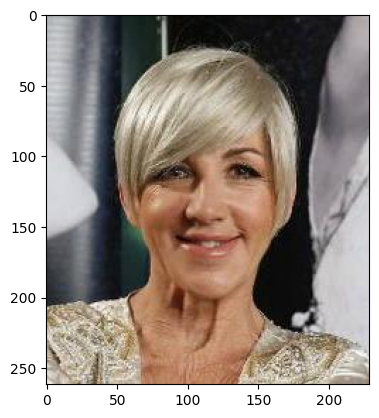

100%|██████████| 10/10 [00:03<00:00,  2.91it/s]


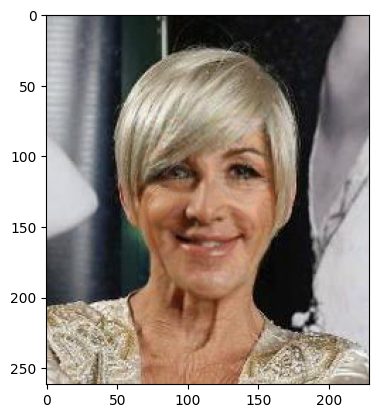

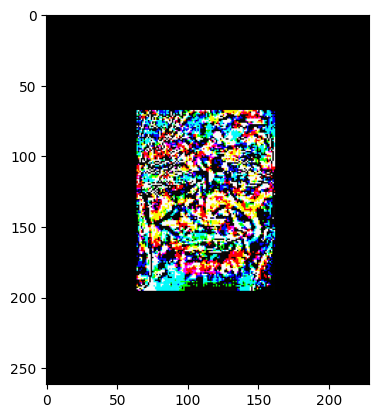

In [4]:
IMAGE_PATH = "../data/vggface_small_flat/n000454_008201.jpg"
SECOND_IMAGE_PATH = "../data/pubfig_small_flat/AngelinaJolie_21.jpg"

orig_im = cv2.imread(IMAGE_PATH)
orig_im = cv2.cvtColor(orig_im, cv2.COLOR_BGR2RGB)
plt.imshow(orig_im)
plt.show()

cloaked_im = cloaker.cloak_image(img_path=IMAGE_PATH, pool_size=100)
plt.imshow(cloaked_im)
plt.show()

diff = np.abs(orig_im - cloaked_im)
# print("diff min, max are:", np.min(diff), np.max(diff))
# diff = np.clip(diff, a_min=230, a_max=255) 
#plt.set_cmap('Grays')
plt.imshow(diff)
plt.show()

# plt.hist(diff.flatten(), bins=100)
# plt.show()

In [5]:
# from skimage.metrics import structural_similarity
# from facenet_pytorch import InceptionResnetV1

# facenet = InceptionResnetV1(pretrained="vggface2").cuda().eval()

# print("Mean perturbation value:", np.mean(orig_im - cloaked_im))
# print("SSIM is", structural_similarity(orig_im, cloaked_im, channel_axis=2))

# second_im = cv2.imread(SECOND_IMAGE_PATH)
# second_im = cv2.cvtColor(second_im, cv2.COLOR_BGR2RGB)

# orig_im = (orig_im - 127.5) / 128.0
# second_im = (second_im - 127.5) / 128.0
# cloaked_im = (cloaked_im - 127.5) / 128.0

# print("IM SHAPE IS", orig_im.shape)
# print("CLOAPED_IM_SHAPE is", cloaked_im.shape)

# orig_embed = facenet(torch.Tensor(orig_im.transpose((2, 0, 1))).unsqueeze(0).cuda())
# cloaked_embed = facenet(torch.Tensor(cloaked_im.transpose((2, 0, 1))).unsqueeze(0).cuda())
# second_embed = facenet(torch.Tensor(second_im.transpose((2, 0, 1))).unsqueeze(0).cuda())

# sim = torch.nn.functional.cosine_similarity(orig_embed, cloaked_embed)
# second_sim = torch.nn.functional.cosine_similarity(second_embed, cloaked_embed)
# print("Similarity to same is:", sim)
# print("Similarity to different is:", second_sim)

In [6]:
from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

2025-08-26 15:33:10.024255: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-26 15:33:22.777716: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-26 15:33:39.127712: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/hice1/zyahn3/.local/lib/python3.10/site-packages/cv2/../../lib64:/opt/slurm/current/lib::
2025-08-26 15:33:39.128244: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic l

In [7]:
from arc2face.Arc2Face.arc2face import CLIPTextModelWrapper, project_face_embs

# Arc2Face is built upon SD1.5
# The repo below can be used instead of the now deprecated 'runwayml/stable-diffusion-v1-5'
base_model = 'stable-diffusion-v1-5/stable-diffusion-v1-5'

encoder = CLIPTextModelWrapper.from_pretrained(
    "arc2face/encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    "arc2face/Arc2Face", torch_dtype=torch.float16
)

pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None
    )

pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline = pipeline.to('cuda')

Loading pipeline components...: 100%|██████████| 6/6 [00:12<00:00,  2.13s/it]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


2025-08-26 15:36:26.900825848 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950457, index: 0, mask: {1, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:26.900906062 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950458, index: 1, mask: {2, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:26.900931211 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950459, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:26.902567834 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950460, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the n

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0


2025-08-26 15:36:27.506794352 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950589, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:27.507794700 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950537, index: 17, mask: {18, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:27.509773332 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950590, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:27.511774568 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950538, index: 18, mask: {19, }, error code: 22 error msg: Invalid argument. Specify t

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/arcface.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0


2025-08-26 15:36:28.536662258 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950646, index: 0, mask: {1, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:28.536683138 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950647, index: 1, mask: {2, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:28.536711242 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950648, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-26 15:36:28.536716893 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2950649, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the n

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)
(262, 229, 3)


100%|██████████| 25/25 [00:01<00:00, 13.43it/s]


Generating 4 took 2.2581090179737657 seconds


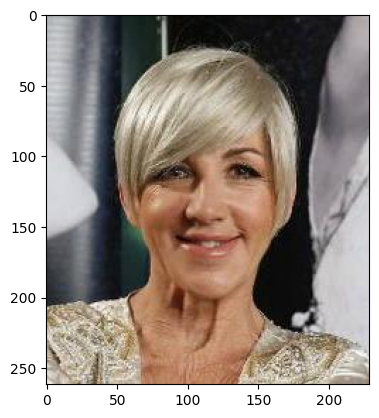

In [11]:
import sys, os
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')
import time

IMAGE_PATH = "../data/vggface_small_flat/n000454_008201.jpg"
#IMAGE_PATH = "../data/pubfig_small_flat/AdamSandler_38.jpg"

from insightface.app import FaceAnalysis
from PIL import Image
app = FaceAnalysis(name='antelopev2', root='./arc2face', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

sys.stderr = stderr

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (img.shape[0] * 20, img.shape[1] * 20))
plt.imshow(img)
print(img.shape)
# img = np.array(Image.open(IMAGE_PATH))[:,:,::-1]
# img = np.array(orig_im)

faces = app.get(img)
faces = sorted(faces, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
id_emb = torch.tensor(faces['embedding'], dtype=torch.float16)[None].cuda()

#id_emb += torch.tensor(np.random.rand(*list(id_emb.size())) / 1, dtype=torch.float16).cuda()
id_emb = id_emb/torch.norm(id_emb, dim=1, keepdim=True)   # normalize embedding

id_emb = project_face_embs(pipeline, id_emb) 
id_emb.requires_grad = True

num_images=4
start = time.perf_counter()
images = pipeline(prompt_embeds=id_emb, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
end = time.perf_counter()
print(f"Generating {num_images} took {end-start} seconds")

tensor([[[-0.3323, -0.0456, -0.0302,  ..., -0.4668, -0.3235,  0.0416],
         [ 0.4631, -0.0085,  1.6631,  ..., -1.2979, -0.4033,  1.2998],
         [ 0.5781, -0.1947,  1.3535,  ...,  0.9243, -1.7568,  0.5562],
         ...,
         [ 0.2366, -1.4629, -1.6240,  ...,  0.4485,  1.3604, -1.0879],
         [ 0.2391, -1.4512, -1.6211,  ...,  0.4585,  1.3652, -1.0771],
         [ 0.2698, -1.4541, -1.6035,  ...,  0.4558,  1.3799, -1.0889]]],
       device='cuda:0', dtype=torch.float16, requires_grad=True)
(512, 512)


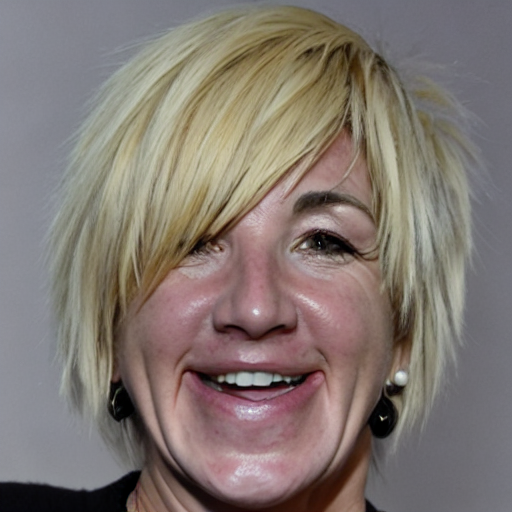

In [15]:
print(id_emb)
print(images[2].size)
images[2]

(262, 229, 3)


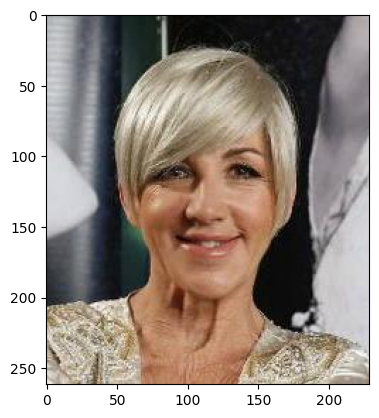

In [10]:
im = cv2.imread(IMAGE_PATH)
print(im.shape)
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)